In [12]:
import os

os.makedirs("../reports/charts", exist_ok=True)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load NAV dataset
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

# Basic check
print("Shape:", nav_df.shape)
print("\nColumns:")
print(nav_df.columns)

print("\nFirst 5 Rows:")
print(nav_df.head())

Shape: (46000, 3)

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

First 5 Rows:
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [3]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
)

fig.show()

In [4]:
performance_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(performance_df.columns)


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [5]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_top100_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'nippon_large_cap_nav.csv', 'sbi_bluechip_nav.csv']


In [6]:
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum_df.head())

print("\nColumns:")
print(aum_df.columns)

print("\nShape:")
print(aum_df.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Shape:
(90, 5)


In [7]:
# Convert date to datetime
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract year
aum_df["year"] = aum_df["date"].dt.year

print(aum_df[["fund_house", "year", "aum_lakh_crore"]].head())

            fund_house  year  aum_lakh_crore
0      SBI Mutual Fund  2022            6.05
1  ICICI Prudential MF  2022            4.65
2     HDFC Mutual Fund  2022            4.35
3      Nippon India MF  2022            2.70
4    Kotak Mahindra MF  2022            2.70


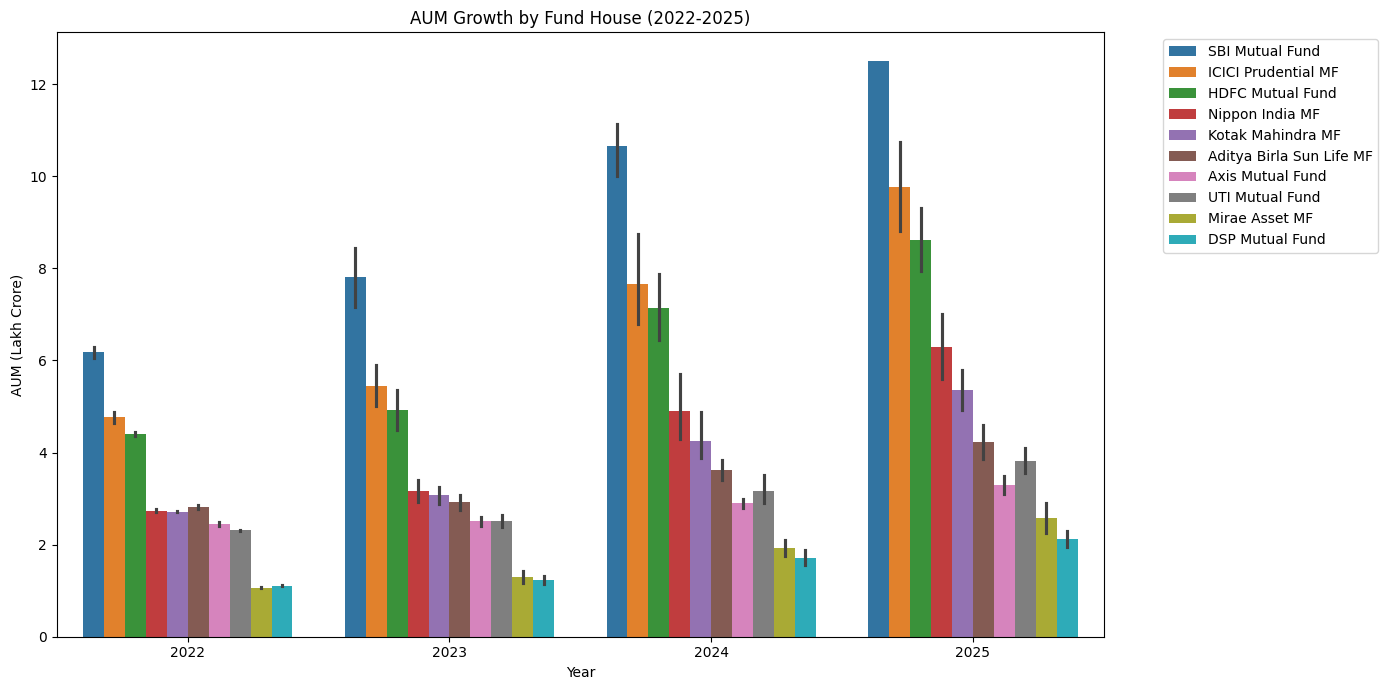

In [8]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

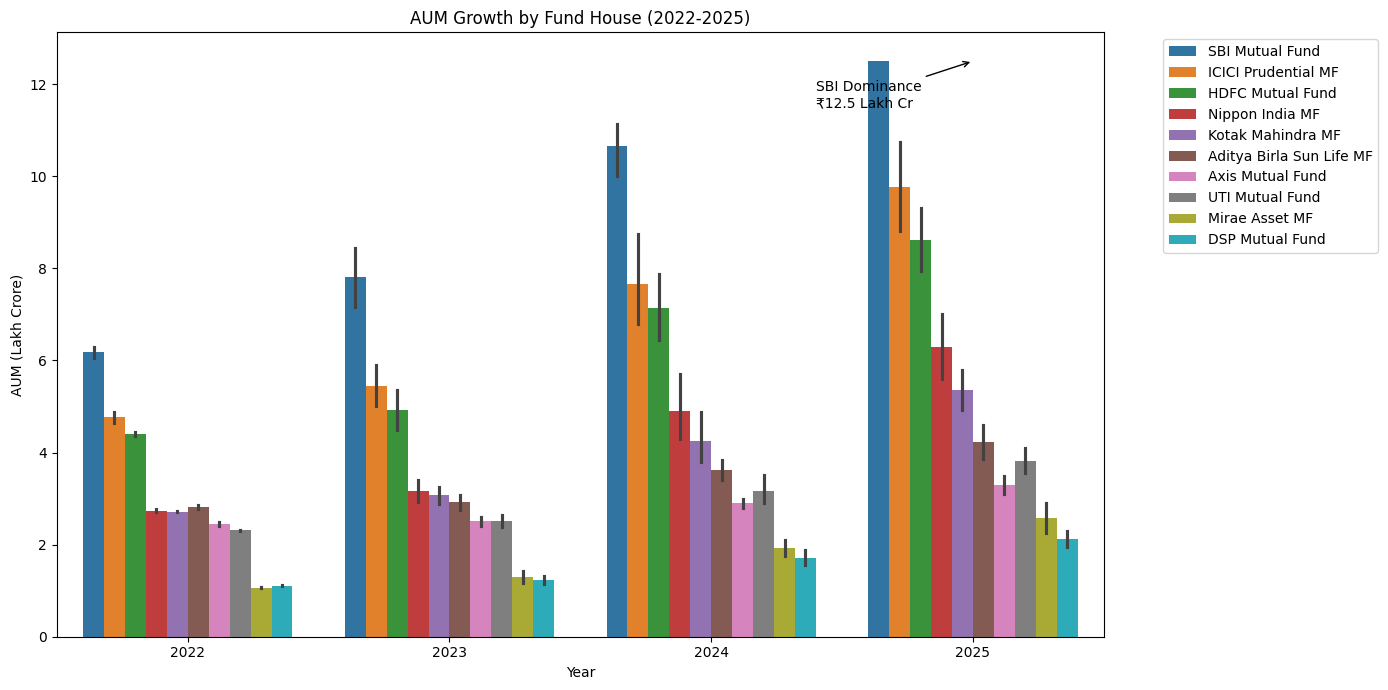

In [9]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.annotate(
    "SBI Dominance\n₹12.5 Lakh Cr",
    xy=(3, 12.5),
    xytext=(2.4, 11.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [10]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip_df.head())

print("\nColumns:")
print(sip_df.columns)

print("\nShape:")
print(sip_df.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

Shape:
(48, 6)


In [11]:
# Convert month column to datetime
sip_df["month"] = pd.to_datetime(sip_df["month"])

# Create SIP trend chart
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

# Highlight all-time high
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [12]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category_df.head())

print("\nColumns:")
print(category_df.columns)

print("\nShape:")
print(category_df.shape)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0

Columns:
Index(['month', 'category', 'net_inflow_crore'], dtype='object')

Shape:
(144, 3)


In [13]:
# Convert month to datetime
category_df["month"] = pd.to_datetime(category_df["month"])

# Create pivot table for heatmap
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heatmap_data.head())

month            2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                      
ELSS                  466.0       553.0       472.0       471.0       499.0   
Flexi Cap            4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                  784.0       836.0       864.0       959.0       952.0   
Hybrid               2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap      4214.0      4368.0      4610.0      5023.0      5411.0   

month            2024-09-01  2024-10-01  2024-11-01  2024-12-01  2025-01-01  \
category                                                                      
ELSS                  537.0       537.0       571.0       521.0       516.0   
Flexi Cap            5397.0      6004.0      6111.0      4654.0      5603.0   
Gilt                  925.0       898.0       704.0       831.0       744.0   
Hybrid               3015.0      3314.0      3264.0

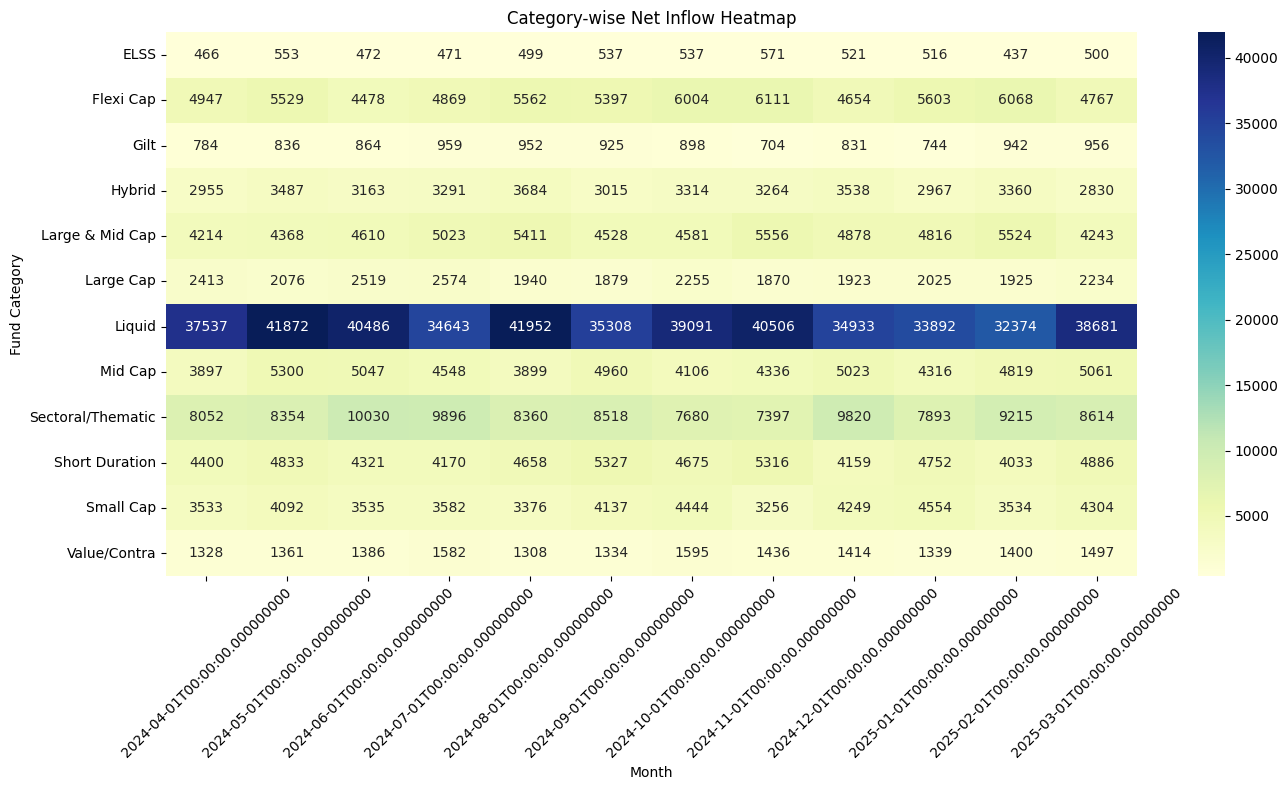

In [14]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(investor_df.columns)
print("\nShape:", investor_df.shape)
print("\nFirst 5 Rows:")
print(investor_df.head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Shape: (32778, 13)

First 5 Rows:
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male     

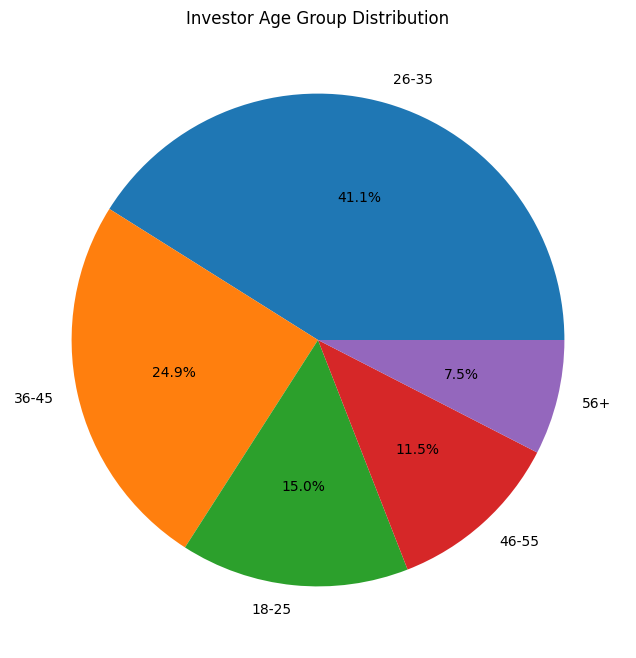

In [16]:
age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

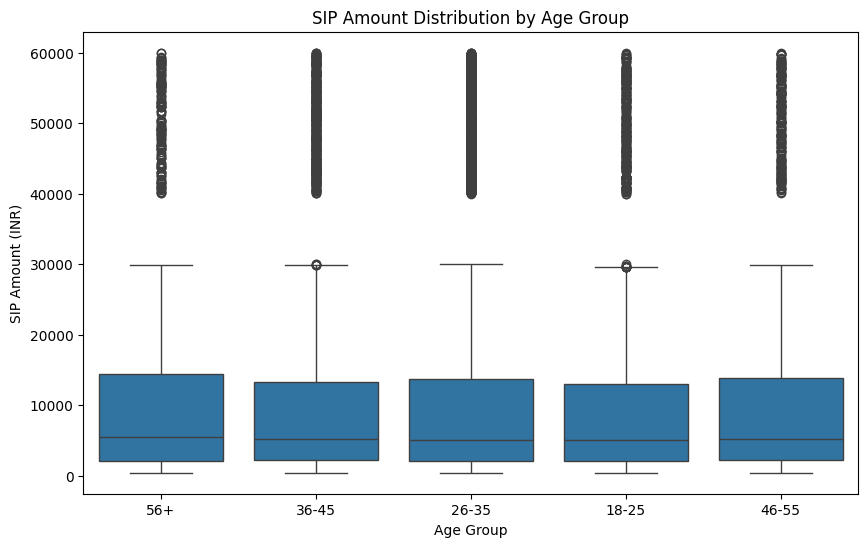

In [17]:
sip_df = investor_df[investor_df["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.show()

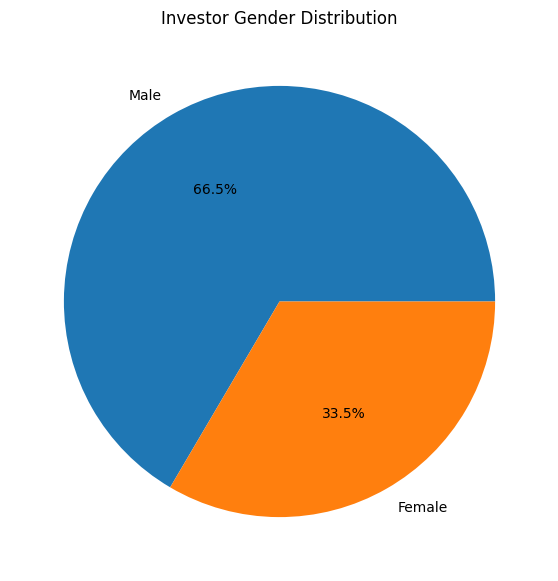

In [18]:
gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.show()

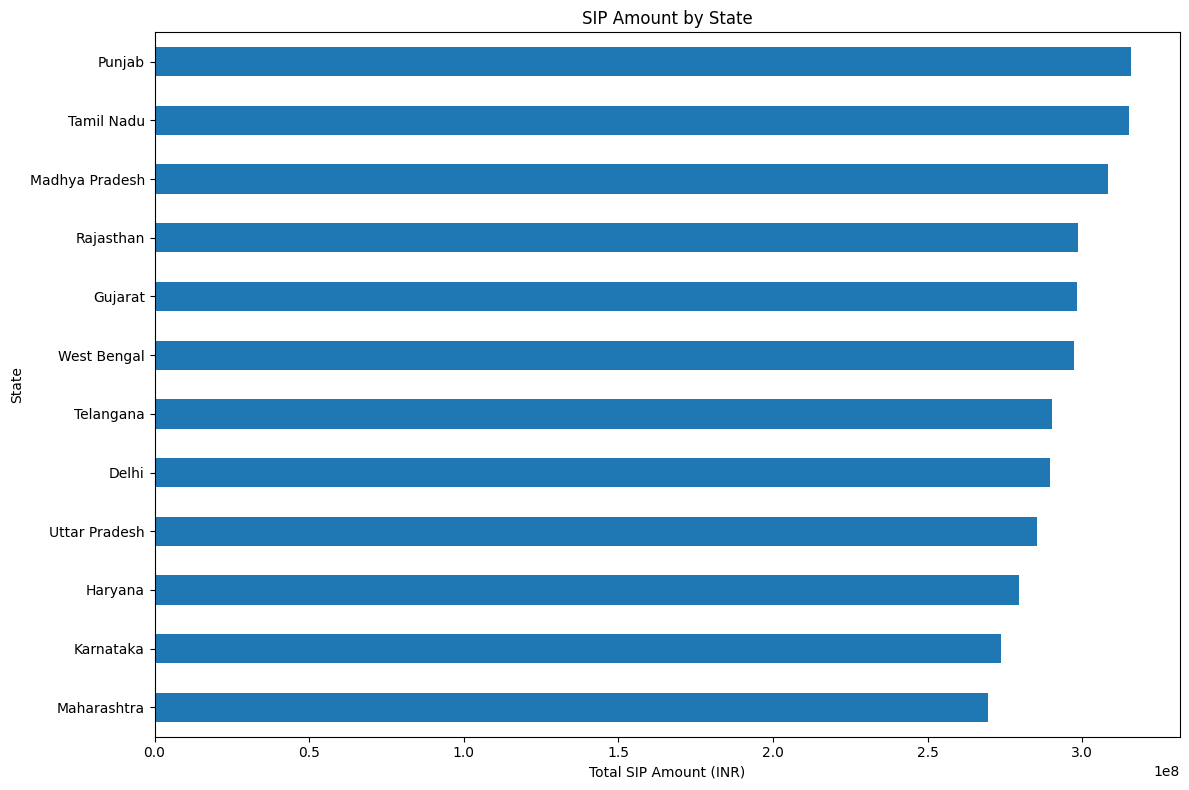

In [19]:
state_sip = investor_df.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

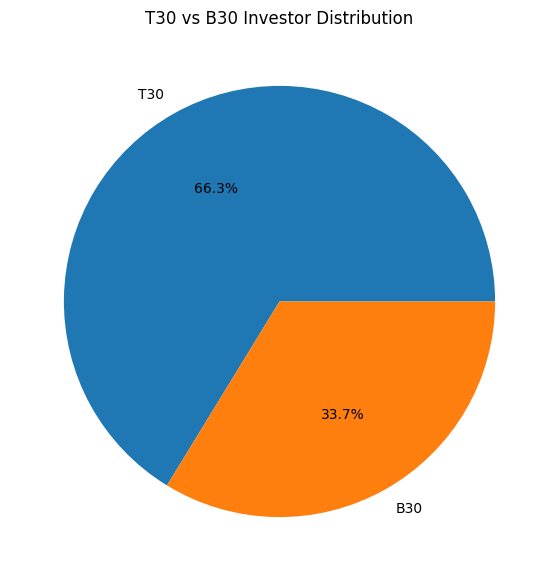

In [20]:
city_tier_counts = investor_df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [21]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.head())

print("\nColumns:")
print(folio_df.columns)

print("\nShape:")
print(folio_df.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

Shape:
(21, 6)


In [22]:
# Convert month column to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

# Create folio growth chart
fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Count Growth (2022-2025)",
    markers=True
)

# Mark starting point
fig.add_annotation(
    x=folio_df["month"].iloc[0],
    y=folio_df["total_folios_crore"].iloc[0],
    text="13.26 Cr (Jan 2022)",
    showarrow=True
)

# Mark latest milestone
fig.add_annotation(
    x=folio_df["month"].iloc[-1],
    y=folio_df["total_folios_crore"].iloc[-1],
    text="26.12 Cr Milestone",
    showarrow=True
)

fig.show()

In [23]:
# Create pivot table
nav_pivot = nav_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(nav_pivot.shape)

(1150, 40)


In [24]:
# Daily percentage returns
returns_df = nav_pivot.pct_change()

print(returns_df.head())

amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2022-01-04 -0.010306 -0.003553 -0.013328  0.001153 -0.010865 -0.000141   
2022-01-05  0.012865 -0.000050 -0.004386  0.003866  0.000603  0.000382   
2022-01-06 -0.011377 -0.001880 -0.005167 -0.002128 -0.029101 -0.000143   
2022-01-07 -0.001210  0.002036 -0.005748 -0.006314  0.024766  0.000215   

amfi_code     102885    102886    102887    118632  ...    120843    120844  \
date                                                ...                       
2022-01-03       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2022-01-04  0.011122  0.011314 -0.010459 -0.000714  ...  0.018160  0.000243   
2022-01-05 -0.007878  0.006779 -0.005308  0.005913  ... -0.012304  0.000462   
2022-01-06  0.015277  0.031127  0.012678  0.003540  ...  0.008509  0.000650   
2022-01

In [25]:
# Select first 10 funds
selected_funds = returns_df.columns[:10]

# Correlation matrix
corr_matrix = returns_df[selected_funds].corr()

print(corr_matrix)

amfi_code    100016    100025    100033    101206    101207    101208  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006  0.027747  0.016053 -0.033773   
100025     0.045567  1.000000  0.002150  0.023769 -0.006710  0.018455   
100033    -0.000006  0.002150  1.000000 -0.018079  0.000351  0.007864   
101206     0.027747  0.023769 -0.018079  1.000000  0.010202 -0.027230   
101207     0.016053 -0.006710  0.000351  0.010202  1.000000 -0.007530   
101208    -0.033773  0.018455  0.007864 -0.027230 -0.007530  1.000000   
102885    -0.093533 -0.001038 -0.034228  0.001570 -0.005929 -0.001436   
102886    -0.005867  0.013754 -0.018166  0.007229  0.004860  0.014307   
102887    -0.023316 -0.005648 -0.036647 -0.006490  0.002304  0.036547   
118632    -0.026781 -0.014166 -0.013318 -0.005432  0.043384  0.003507   

amfi_code    102885    102886    102887    118632  
amfi_code                                          
100016    -0.093533

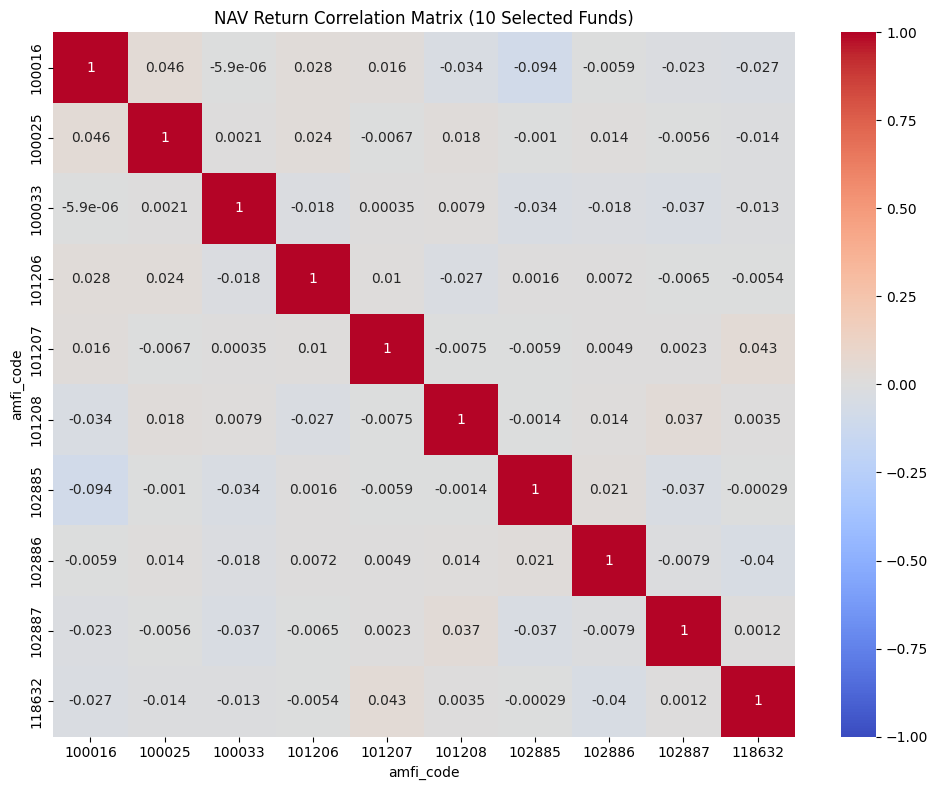

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")
plt.tight_layout()

plt.show()

In [27]:
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings_df.head())

print("\nColumns:")
print(holdings_df.columns)

print("\nShape:")
print(holdings_df.shape)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns:
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

Shape:
(322, 8)


In [28]:
sector_weights = (
    holdings_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_weights)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


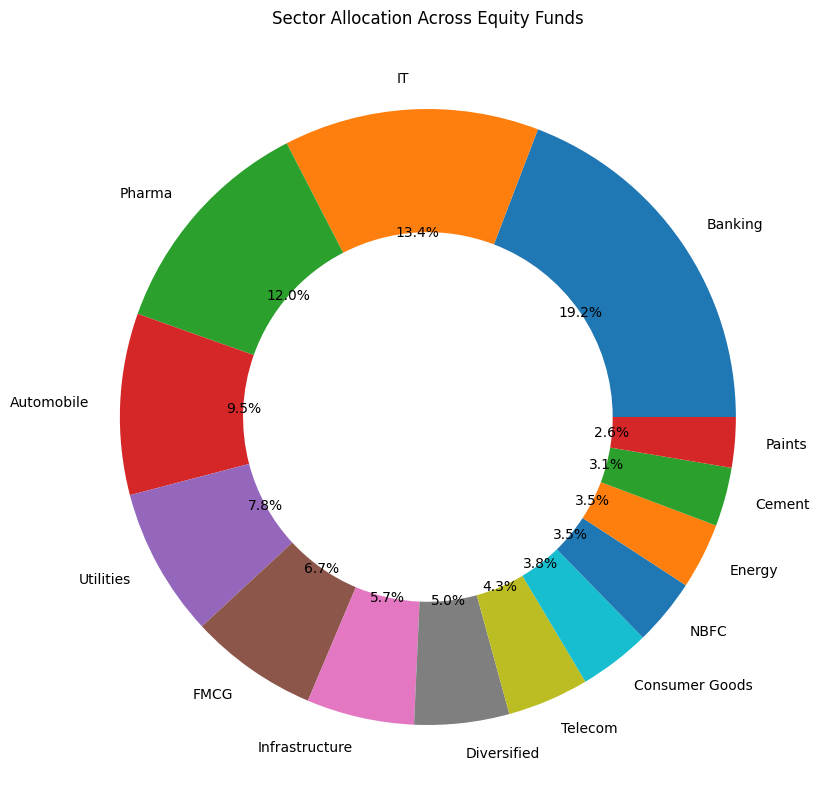

In [29]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

In [33]:
monthly_sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

monthly_sip_df["month"] = pd.to_datetime(monthly_sip_df["month"])

print(monthly_sip_df.head())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [34]:
fig = px.line(
    monthly_sip_df,
    x="month",
    y="active_sip_accounts_crore",
    title="Active SIP Accounts Growth (2022-2025)",
    markers=True
)

fig.show()

In [35]:
fig = px.line(
    monthly_sip_df,
    x="month",
    y="sip_aum_lakh_crore",
    title="SIP AUM Growth (2022-2025)",
    markers=True
)

fig.show()

In [36]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
folio_df["month"] = pd.to_datetime(folio_df["month"])

In [37]:
fig = px.line(
    folio_df,
    x="month",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore"
    ],
    title="Folio Growth by Category (2022-2025)",
    markers=True
)

fig.show()

# Key EDA Findings

## 1.
Daily NAV trends showed a strong market rally during 2023, indicating a bullish phase across most mutual fund schemes.
(Reference: Chart 01 - NAV Trend Analysis)

## 2.
SBI Mutual Fund remained the largest fund house with AUM crossing ₹12.5 lakh crore, significantly ahead of competitors.
(Reference: Chart 02 - AUM Growth)

## 3.
Monthly SIP inflows increased consistently from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025.
(Reference: Chart 04 - SIP Inflow Trend)

## 4.
Flexi Cap, Mid Cap and Large & Mid Cap categories attracted the highest investor inflows during the analysis period.
(Reference: Chart 05 - Category Heatmap)

## 5.
The majority of investors belonged to the 26-35 and 36-45 age groups, showing strong participation from young investors.
(Reference: Chart 06 - Age Distribution)

## 6.
Investors aged 36-45 showed higher SIP contribution amounts compared to other age groups.
(Reference: Chart 07 - SIP Boxplot)

## 7.
Male investors represented a larger share of mutual fund investments compared to female investors.
(Reference: Chart 08 - Gender Distribution)

## 8.
T30 cities contributed a larger share of investments than B30 cities, highlighting metro city dominance.
(Reference: Chart 10 - T30 vs B30 Distribution)

## 9.
Industry folio count almost doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025.
(Reference: Chart 11 - Folio Growth)

## 10.
Banking, IT and Pharma sectors accounted for the largest portfolio allocations across equity mutual funds.
(Reference: Chart 13 - Sector Allocation)